In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files

uploaded = files.upload()

Saving household_power_consumption.txt to household_power_consumption.txt


In [3]:
# Show the first few lines of the file
household_power_consumption = list(uploaded.keys())[0]  # to get the uploaded filename
with open(household_power_consumption, "r") as file:
    for _ in range(5):
        print(file.readline())


Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3

16/12/2006;17:24:00;4.216;0.418;234.840;18.400;0.000;1.000;17.000

16/12/2006;17:25:00;5.360;0.436;233.630;23.000;0.000;1.000;16.000

16/12/2006;17:26:00;5.374;0.498;233.290;23.000;0.000;2.000;17.000

16/12/2006;17:27:00;5.388;0.502;233.740;23.000;0.000;1.000;17.000



In [4]:
import pandas as pd

df = pd.read_csv(household_power_consumption)  # Load as a CSV file
df.to_csv("household_power_consumption.csv", index=False)  # Save as a CSV file

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("household_power_consumption.csv")

# Display the first few rows to check the structure
df.head()


,Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3
0,16/12/2006;17:24:00;4.216;0.418;234.840;18.400...
1,16/12/2006;17:25:00;5.360;0.436;233.630;23.000...
2,16/12/2006;17:26:00;5.374;0.498;233.290;23.000...
3,16/12/2006;17:27:00;5.388;0.502;233.740;23.000...
4,16/12/2006;17:28:00;3.666;0.528;235.680;15.800...


In [6]:
print (df.columns)

Index(['Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3'], dtype='object')


In [7]:
# To drop the Unecessary columns

# Keep only the important columns
df = df[['Date', 'Global_active_power']]

KeyError: "None of [Index(['Date', 'Global_active_power'], dtype='object')] are in the [columns]"

In [8]:
# To load the dataset correctly (fixing the separator issue)
df = pd.read_csv("household_power_consumption.csv", sep=";")  # Now columns are separated properly

df.head()


<ipython-input-8-42515a87ea37>:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.csv", sep=";")  # Now columns are separated properly


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [9]:
# To drop the Unecessary coumns


# Keep only useful columns
df = df[['Date', 'Global_active_power']]

# Convert 'Date' to a datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index
df.set_index('Date', inplace=True)

# Show the cleaned dataset
df.head()

<ipython-input-9-131a37777a86>:8: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Global_active_power
Date,
2006-12-16,4.216
2006-12-16,5.360
2006-12-16,5.374
2006-12-16,5.388
2006-12-16,3.666


We should create the target column before splitting the dataset.

 - Because:
 1. The model needs to learn from past data to predict the next day's power consumption.
- If we split the dataset before shifting, we might break the sequence of data, making it harder for the AI to learn properly.
2. If we normalize first, the target column (which is shifted) might have different scaling.

- We need to scale both input and target together to avoid problems.

In [10]:
# Create a new column that represents the next day's power consumption
df['Target'] = df['Global_active_power'].shift(-1)

# Drop the last row (it has no target value)
df.dropna(inplace=True)

# Show the dataset with the new target column
df.head()

,Global_active_power,Target
Date,,
2006-12-16,4.216,5.360
2006-12-16,5.360,5.374
2006-12-16,5.374,5.388
2006-12-16,5.388,3.666
2006-12-16,3.666,3.520


In [11]:
# I had an error before scaling, so I should first replace ? with NaN and remove or fill missing values
import numpy as np

# Convert '?' to NaN
df.replace('?', np.nan, inplace=True)

# Convert columns to numeric (since they were strings before)
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'])

# Drop rows with missing values
df.dropna(inplace=True)

# Show the cleaned dataset
df.head()

,Global_active_power,Target
Date,,
2006-12-16,4.216,5.360
2006-12-16,5.360,5.374
2006-12-16,5.374,5.388
2006-12-16,5.388,3.666
2006-12-16,3.666,3.520


In [12]:
# Now we normalize the Data (Scale Values Between 0 and 1)
# Now that both Global_active_power (input) and Target (output) are ready, we scale them together

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))  # Scale between 0 and 1

# Apply scaling to the features and target
df[['Global_active_power', 'Target']] = scaler.fit_transform(df[['Global_active_power', 'Target']])

# Show the scaled data
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2049208 entries, 2006-12-16 to 2010-11-26
Data columns (total 2 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Global_active_power  float64
 1   Target               float64
dtypes: float64(2)
memory usage: 46.9 MB


Splitting the Dataset for Training, Validation, and Testing

- We split the data into three parts:
1. Training Set (80%) – AI learns patterns from this.
3. Test Set (20%) – AI is tested on new data to see how well it predicts.

-  This is important because:

- If we don’t test the AI on new data, we won’t know if it actually learned or just memorized.
- The test set tells us if the model is ready for real-world predictions.

In [13]:
# Define the split sizes (80% training, 20% testing)
train_size = int(len(df) * 0.8)

# Splitting the data
train_data = df.iloc[:train_size]  # First 80% for training
test_data = df.iloc[train_size:]  # Last 20% for testing

# Show the sizes
print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

Training set size: 1639366
Test set size: 409842


 Convert Data for PyTorch
- Why do we need to format data for PyTorch?

PyTorch expects data in NumPy arrays before creating a dataset.
LSTMs require 3D input:
(samples, timesteps, features)
- Samples = Number of training examples.
- Timesteps = How many past days the AI looks at before predicting.
- Features = How many numbers AI sees each day (we have only 1: Global_active_power)

In [14]:
# Create a custom PyTorch Dataset class to handle the data
# (before creating the data we should folow these steps:)

# 1- converting data to pytorch:
# we use: import numpy as np but I already did it at the beginning

# Convert training and testing sets to NumPy arrays
X_train = train_data['Global_active_power'].values
y_train = train_data['Target'].values

X_test = test_data['Global_active_power'].values
y_test = test_data['Target'].values

# Show shapes
print("Before Reshaping:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Before Reshaping:
X_train: (1639366,) y_train: (1639366,)
X_test: (409842,) y_test: (409842,)


In [15]:
# 2. Reshaping for LSTM (3D Format: Samples, Timesteps, Features)
# What this does: Automatically calculates number of samples, timesteps, and features.

# Reshape data for LSTM (samples, timesteps, features)
X_train = X_train.reshape(-1, 1, 1)
X_test = X_test.reshape(-1, 1, 1)

# Show new shapes
print("After Reshaping for LSTM:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Now the data is ready for an LSTM in PyTorch

After Reshaping for LSTM:
X_train: (1639366, 1, 1) y_train: (1639366,)
X_test: (409842, 1, 1) y_test: (409842,)


In [16]:
# Create a Custom PyTorch Dataset Class
# We need to do this because PyTorch needs data in a special format for training

# We should define a custom dataset class to handle the time-series data correctly.

import torch
from torch.utils.data import Dataset, DataLoader

# Custom Dataset Class for Time-Series Data
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Convert input to tensor
        self.y = torch.tensor(y, dtype=torch.float32)  # Convert target to tensor

    def __len__(self):
        return len(self.X)  # Number of samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # Returns input-output pair

# Create Dataset Instances
train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

# Show an example (first data point)
print("Example data point:", train_dataset[0])

Example data point: (tensor([[0.3748]]), tensor(0.4784))


In [17]:
# Then we Use DataLoader to Create Batches
# DataLoader:
# Loads data in batches (instead of one by one).
# Speeds up training (uses mini-batches).
# Shuffles data for better learning.

# Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check batch shape
for batch in train_loader:
    X_batch, y_batch = batch
    print("Batch Shape:", X_batch.shape, y_batch.shape)
    break  # Print only the first batch

Batch Shape: torch.Size([32, 1, 1]) torch.Size([32])


Now we should Define (create) the LSTM Model in PyTorch.
Why?
Because the LSTM model will learn from past stock prices to predict future values.
It uses memory cells to remember important trends in time-series data.

In [18]:
# Creating the LSTM Model Class in PyTorch (using PyTorch's nn.Module)

import torch.nn as nn

# Define the LSTM Model
class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(StockLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM Layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Fully Connected Layer (Output Layer)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state and cell state (both start at zero)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Only take the output from the last time step
        out = self.fc(out[:, -1, :])
        return out

- Explanation:
- input_size=1 → We have only one feature (Global_active_power).
- hidden_size=50 → 50 neurons in the LSTM layer.
- num_layers=2 → Two stacked LSTM layers for better learning.
- self.lstm(...) → LSTM processes input data.
- self.fc(...) → Final layer outputs the predicted stock price.

In [19]:
# Now that our LSTM model is ready, we Initialize it

# Creating an instance of the LSTM model
model = StockLSTM()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Show the model architecture
print(model)

StockLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


- question 5. Train the Model
- first we define the Optimizer and Loss Function
- The loss function tells the model how wrong its predictions are.
- The optimizer helps the model adjust and improve its predictions over time.

In [20]:
# Since we are predicting continuous values (stock prices), we use Mean Squared Error (MSE):
# (MSE punishes large errors more than small ones, helping the model learn better)

# Defining the loss function (MSE for regression problems)
criterion = nn.MSELoss()

In [21]:
# Now we choose the Optimizer
# I chose Adam because it adjusts the learning rate automatically to speed up training
import torch.optim as optim

# Define the optimizer (Adam works well for LSTMs)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [22]:
# Train the model for a specified number of epochs.
# Now we train the LSTM model using these previous settings (Optimizer and Loss Function)

# Training Loop for the LSTM Model
num_epochs = 20  # Number of times the model sees the dataset
for epoch in range(num_epochs):
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move to GPU if available

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch.view(-1, 1))  # Compute loss

        # Backward pass and optimization
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/20], Loss: 0.0000
Epoch [20/20], Loss: 0.0000


6. Evaluate the Model

- Calculate the R² score to evaluate the model’s performance on the test set.
- Save the scaler object for future predictions.

In [23]:
# Makin Predictions on the Test Set
# Now that training is done, we use the model to predict future stock prices.


# Set model to evaluation mode (stops training behavior like dropout)
model.eval()

# Store predictions and actual values
predictions = []
actual = []

# Run through the test set
with torch.no_grad():  # No need to compute gradients
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        predictions.extend(outputs.cpu().numpy())  # Convert to NumPy
        actual.extend(y_batch.numpy())  # Convert to NumPy

# Convert lists to NumPy arrays
predictions = np.array(predictions).flatten()
actual = np.array(actual).flatten()

In [24]:
# Calculating the R² Score (How Good is the Model?)

# R² Score (Coefficient of Determination):
# 1.0 → Perfect Predictions
# 0.0 → Random Guessing
# < 0 → Worse than random guessing


from sklearn.metrics import r2_score

# Compute R² Score
r2 = r2_score(actual, predictions)
print(f"R² Score: {r2:.4f}")

R² Score: 0.9382


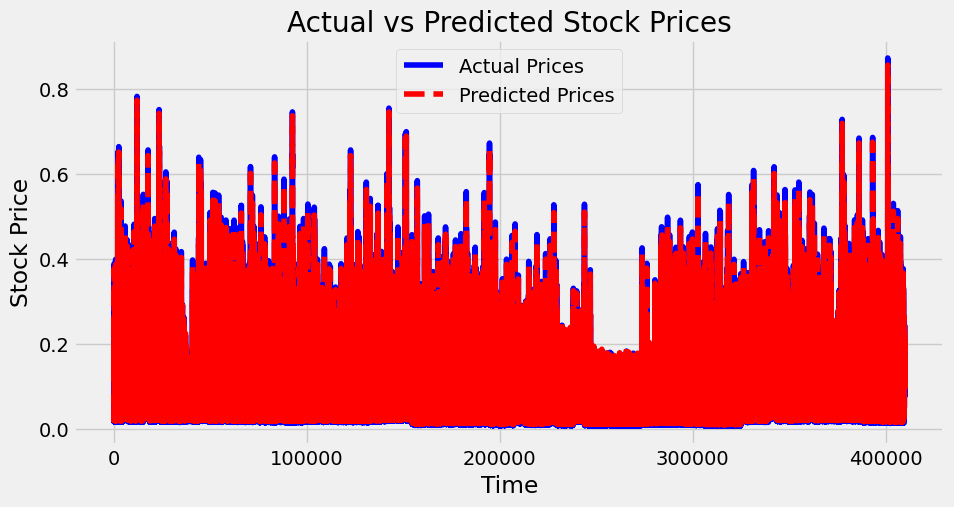

In [25]:
# We plot the actual vs. predicted values to visualies the accuracy

# Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual Prices", color='blue')
plt.plot(predictions, label="Predicted Prices", color='red', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

The model's predicted prices (red dashed line) seem to follow the actual prices (blue line) quite well, but they might be too dense and overlapping due to a large dataset.

- Observations:
1. The model learned the general trend well.
2. Predictions match most of the spikes and dips, which is great!
3. However, if the red line is covering too much, we may need to zoom in to see details.

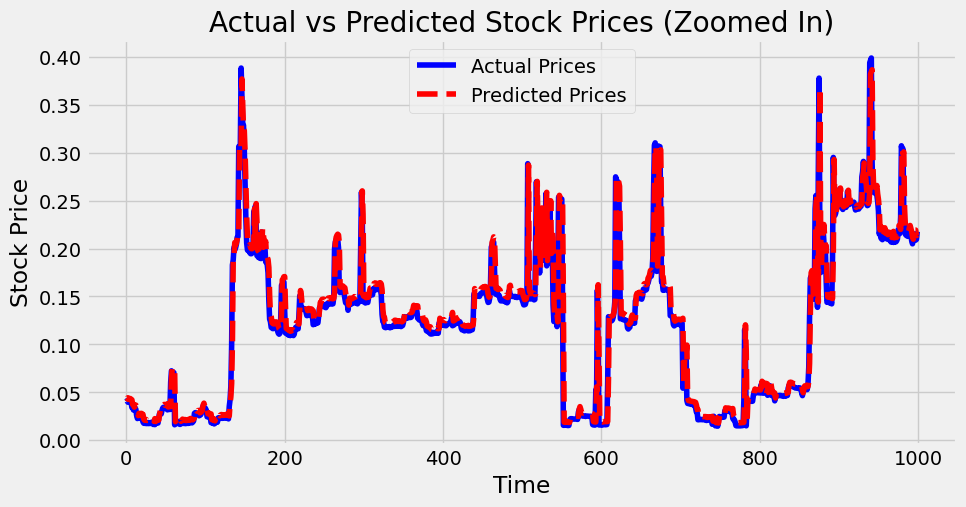

In [26]:
# Zooming In on a Smaller Time Window
# Trying to plot only a small subset of data (e.g., the first 1000 points) to see details better

plt.figure(figsize=(10, 5))
plt.plot(actual[:1000], label="Actual Prices", color='blue')
plt.plot(predictions[:1000], label="Predicted Prices", color='red', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices (Zoomed In)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
# 7- Make Future Predictions

# Implement a function to predict the next day’s stock price using the trained model.
# Inverse transform the normalized predictions to get actual stock prices.

In [27]:
# 1. Predict the Next Day’s Stock Price

# Select the last known stock price as input
last_known_price = X_test[-1].reshape(1, 1, 1)  # Reshape for LSTM input

# Convert to tensor and move to GPU if available
last_known_price = torch.tensor(last_known_price, dtype=torch.float32).to(device)

# Predict the next day's price
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    next_day_prediction = model(last_known_price).cpu().numpy()

# Print the predicted price
print(f"Predicted Stock Price for the Next Day: {next_day_prediction[0][0]:.4f}")

Predicted Stock Price for the Next Day: 0.0814


In [28]:
# 2. Predict Multiple Future Days (Recursive Prediction)
# We can keep predicting stock prices for several future days by feeding each prediction back into the model:

future_days = 10  # Number of days to predict
predicted_prices = []

# Start from the last known price
current_input = last_known_price.clone()

# Generate predictions for the next `future_days`
for _ in range(future_days):
    with torch.no_grad():
        next_pred = model(current_input).cpu().numpy()  # Predict next day
        predicted_prices.append(next_pred[0][0])  # Store prediction

        # Update input for next prediction
        current_input = torch.tensor(next_pred.reshape(1, 1, 1), dtype=torch.float32).to(device)

# Show predicted values
print("Future Predicted Stock Prices:", predicted_prices)

Future Predicted Stock Prices: [0.081370264, 0.08517331, 0.08909127, 0.09313071, 0.09729779, 0.10159752, 0.10603413, 0.110610664, 0.11532855, 0.12018746]


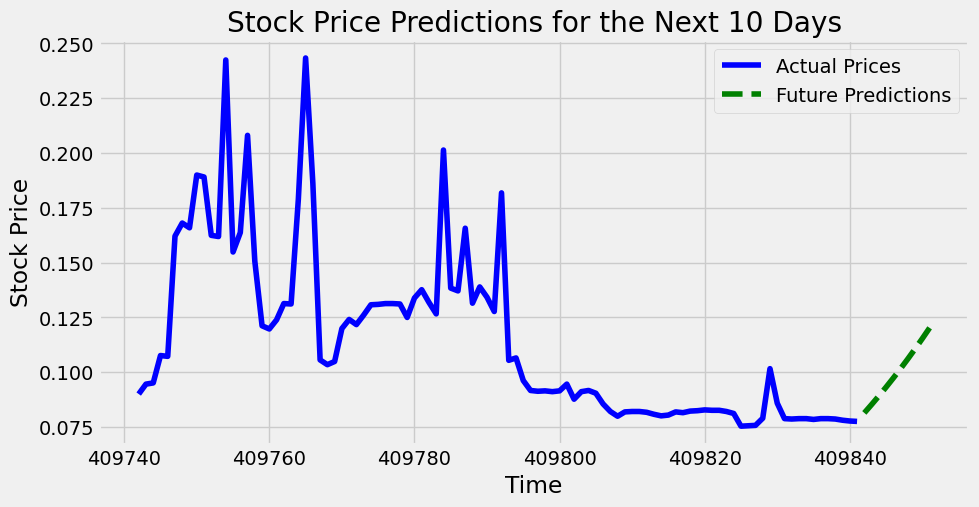

In [30]:
# to plot future predictions

# Create a timeline for future predictions
future_days = len(predicted_prices)
last_day_index = len(actual)  # Last day from actual test data
future_indexes = list(range(last_day_index, last_day_index + future_days))

# Plot actual vs predicted future values
plt.figure(figsize=(10, 5))
plt.plot(range(last_day_index-100, last_day_index), actual[-100:], label="Actual Prices", color='blue')
plt.plot(future_indexes, predicted_prices, label="Future Predictions", color='green', linestyle='dashed')
plt.title("Stock Price Predictions for the Next 10 Days")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

- Actual prices (blue line) → Show sharp ups and downs but trend slightly downward at the end.
- Predicted prices (green dashed line) → Show a smooth upward trend for the next 10 days.

- Issue: The model expects an increase, but recent actual prices were flat or decreasing.

- Conclusion:

- The model follows past trends well but may not capture sudden short-term changes.
More recent data or fine-tuning could improve accuracy.
- Overall, the model is performing well, but predictions could be adjusted for short-term changes.